## **BAB 4. Wrangling Data II: Transformasi dan Rekayasa Fitur**

In [ ]:
import pandas as pd

# URL dataset
dataset_url = 'https://raw.githubusercontent.com/wmaharani/prinsip-sains-data/main/data/transaksi_ecommerce_id.csv'

# Membaca dataset dengan pemisah titik koma
df = pd.read_csv(dataset_url, sep=';')

# Menampilkan nama-nama kolom
print("Kolom yang tersedia dalam dataset:")
for col in df.columns:
    print(col)

Kolom yang tersedia dalam dataset:
order_id
total_qty
total_weight_gr
total_returned_qty
Total Diskon
product_categories
num_product_categories
Status Pesanan
Alasan Pembatalan
Opsi Pengiriman
Metode Pembayaran
Kota/Kabupaten
Provinsi
Ongkos Kirim Dibayar oleh Pembeli
Estimasi Potongan Biaya Pengiriman
Total Pembayaran
Perkiraan Ongkos Kirim
Waktu Pesanan Dibuat
order_date


### Seleksi Kolom untuk Transformasi Data

Langkah ini bertujuan untuk memilih subset kolom dari DataFrame asli (`df`) yang relevan untuk analisis atau pemrosesan lebih lanjut. Dengan memilih hanya kolom yang diperlukan, kita dapat mengurangi ukuran data, meningkatkan kinerja, dan memfokuskan perhatian pada variabel-variabel kunci. Dalam contoh ini, kita akan memilih `order_id`, `total_qty`, `Total Pembayaran`, dan `order_date`.

In [ ]:
# Memilih beberapa kolom untuk transformasi data
selected_columns = ['order_id', 'total_qty', 'Total Pembayaran', 'order_date']
df_selected = df[selected_columns]

# Menampilkan 5 baris pertama dari DataFrame yang telah dipilih kolomnya
print("DataFrame dengan kolom yang dipilih:")
print(df_selected.head())

DataFrame dengan kolom yang dipilih:
      order_id  total_qty  Total Pembayaran  order_date
0  ORD_0000001        2.0             38300  2024-04-01
1  ORD_0000002        1.0             18576  2024-04-01
2  ORD_0000003        1.0              7069  2024-04-01
3  ORD_0000004        2.0             32200  2024-04-01
4  ORD_0000005        3.0                 0  2024-04-01


### Seleksi Baris Berdasarkan Kategori

Seleksi baris berdasarkan kategori adalah proses memfilter baris-baris dalam DataFrame yang memenuhi kriteria tertentu pada kolom kategorikal. Ini memungkinkan kita untuk menganalisis subset data yang spesifik, misalnya, hanya melihat pesanan dengan status 'Selesai' atau produk dari kategori tertentu. Dalam contoh ini, kita akan memfilter DataFrame untuk hanya menampilkan pesanan yang memiliki `Status Pesanan` 'Selesai'.

In [ ]:
# Seleksi baris berdasarkan kategori 'Status Pesanan' yang bernilai 'Selesai'
df_selesai = df[df['Status Pesanan'] == 'Selesai']

# Menampilkan 5 baris pertama dari DataFrame yang telah difilter
print("DataFrame dengan Status Pesanan 'Selesai':")
print(df_selesai.head())

DataFrame dengan Status Pesanan 'Selesai':
      order_id  total_qty  total_weight_gr  total_returned_qty  Total Diskon  \
0  ORD_0000001        2.0             2000                   0             0   
1  ORD_0000002        1.0              500                   0             0   
2  ORD_0000003        1.0              500                   0             0   
3  ORD_0000004        2.0              400                   0             0   
5  ORD_0000006        2.0             1000                   0             0   

      product_categories  num_product_categories Status Pesanan  \
0               Celengan                       1        Selesai   
1               Celengan                       1        Selesai   
2               Celengan                       1        Selesai   
3  Mangkok Sambal / Saus                       1        Selesai   
5               Celengan                       1        Selesai   

  Alasan Pembatalan                  Opsi Pengiriman      Metode Pembayar

### Seleksi Baris Berdasarkan Rentang Tanggal

Memfilter data berdasarkan rentang tanggal adalah operasi umum dalam analisis data deret waktu. Ini memungkinkan kita untuk fokus pada periode waktu tertentu, misalnya, untuk menganalisis tren bulanan atau musiman. Dalam langkah ini, kita akan memilih baris-baris di mana `order_date` berada dalam bulan April 2024. Pertama, kita perlu memastikan kolom `order_date` diubah ke format datetime yang benar, lalu kita dapat melakukan filtering.

In [ ]:
# Pastikan kolom 'order_date' bertipe datetime (menangani mixed formats dan error)
df['order_date'] = pd.to_datetime(df['order_date'], format='mixed', dayfirst=True, errors='coerce')

# Menentukan rentang tanggal
start_date = '2024-04-01'
end_date = '2024-04-30'

# Seleksi baris berdasarkan rentang tanggal, mengabaikan nilai NaT
df_date_range = df[(df['order_date'] >= start_date) & (df['order_date'] <= end_date)]

# Menampilkan 5 baris pertama dari DataFrame yang telah difilter berdasarkan rentang tanggal
print("DataFrame dengan pesanan di bulan April 2024:")
print(df_date_range.head())

DataFrame dengan pesanan di bulan April 2024:
      order_id  total_qty  total_weight_gr  total_returned_qty  Total Diskon  \
0  ORD_0000001        2.0             2000                   0             0   
1  ORD_0000002        1.0              500                   0             0   
2  ORD_0000003        1.0              500                   0             0   
3  ORD_0000004        2.0              400                   0             0   
4  ORD_0000005        3.0             3600                   0             0   

              product_categories  num_product_categories Status Pesanan  \
0                       Celengan                       1        Selesai   
1                       Celengan                       1        Selesai   
2                       Celengan                       1        Selesai   
3          Mangkok Sambal / Saus                       1        Selesai   
4  Keranjang, Other, Tempat Nasi                       3          Batal   

                      

### Seleksi Transaksi Bernilai Besar

Untuk mengidentifikasi transaksi yang memiliki nilai pembayaran tinggi (transaksi bernilai besar), kita dapat menetapkan ambang batas (`threshold`) pada kolom `Total Pembayaran`. Ini sangat berguna untuk analisis seperti deteksi anomali, identifikasi pelanggan bernilai tinggi, atau analisis profitabilitas. Dalam langkah ini, kita akan memfilter DataFrame untuk menemukan semua transaksi di mana `Total Pembayaran` melebihi nilai ambang batas yang ditentukan.

In [ ]:
# Menentukan ambang batas untuk transaksi bernilai besar (contoh: di atas 100.000)
threshold_besar = 100000

# Seleksi baris transaksi yang bernilai besar
df_transaksi_besar = df[df['Total Pembayaran'] > threshold_besar]

# Menampilkan 5 baris pertama dari DataFrame transaksi bernilai besar
print(f"DataFrame dengan transaksi bernilai lebih dari {threshold_besar}:")
print(df_transaksi_besar.head())

DataFrame dengan transaksi bernilai lebih dari 100000:
       order_id  total_qty  total_weight_gr  total_returned_qty  Total Diskon  \
17  ORD_0000018        1.0             7000                   0             0   
24  ORD_0000025       15.0             3000                   0             0   
25  ORD_0000026       10.0             2000                   0             0   
37  ORD_0000038        2.0             4000                   1             0   
40  ORD_0000041        3.0              150                   0             0   

         product_categories  num_product_categories Status Pesanan  \
17                    Other                       1        Selesai   
24            Nampan / Tray                       1        Selesai   
25    Mangkok Sambal / Saus                       1        Selesai   
37  Plastik / Wadah Plastik                       1        Selesai   
40    Stempel / Alat Kantor                       1        Selesai   

   Alasan Pembatalan                 

### Transformasi Data: Format Wide dan Long (Melt dan Pivot)

Dalam analisis data, seringkali kita perlu mengubah struktur data dari format "wide" (lebar) ke "long" (panjang), atau sebaliknya. Dua operasi penting untuk ini adalah `melt` dan `pivot_table`.

*   **Format Wide (Lebar)**: Setiap baris mewakili satu entitas, dan setiap kolom mewakili variabel atau pengukuran yang berbeda. Contohnya, data penjualan bulanan di mana setiap bulan memiliki kolomnya sendiri.
*   **Format Long (Panjang / Tidy)**: Setiap baris adalah satu observasi, dan setiap variabel memiliki kolomnya sendiri. Ini seringkali lebih disukai untuk analisis dan visualisasi karena memenuhi prinsip 'tidy data'.

#### `melt()`: Mengubah dari Wide ke Long
Fungsi `melt()` digunakan untuk "melelehkan" (unpivot) DataFrame dari format wide ke long. Ini mengambil satu atau lebih kolom pengenal (`id_vars`) yang akan dipertahankan, dan mengubah kolom-kolom lain (`value_vars`) menjadi dua kolom baru: satu untuk nama variabel (`var_name`) dan satu lagi untuk nilai variabel (`value_name`).

#### `pivot_table()`: Mengubah dari Long ke Wide
Fungsi `pivot_table()` digunakan untuk "memutar" (pivot) DataFrame dari format long kembali ke wide. Ini memungkinkan kita untuk merangkum data dan membentuk tabel ringkasan. Parameter kuncinya meliputi:
*   `index`: Kolom yang akan menjadi indeks DataFrame baru.
*   `columns`: Kolom yang nilainya akan menjadi nama kolom baru.
*   `values`: Kolom yang nilainya akan mengisi sel-sel DataFrame baru.
*   `aggfunc`: Fungsi agregasi yang akan diterapkan jika ada duplikasi nilai (misalnya, 'sum', 'mean', 'count').

In [ ]:
import pandas as pd

# Contoh: Data penjualan bulanan (format Wide)
df_wide = pd.DataFrame({
    'produk'  : ['Kopi', 'Teh', 'Susu'],
    'Jan_2024': [1200, 800, 950],
    'Feb_2024': [1350, 720, 1100],
    'Mar_2024': [1180, 890, 1050],
})
print('Format Wide:\n', df_wide)

# -- MELT: Wide -> Long --
df_long = df_wide.melt(
    id_vars    = ['produk'],      # Kolom yang dipertahankan
    value_vars = ['Jan_2024', 'Feb_2024', 'Mar_2024'],
    var_name   = 'bulan',         # Nama kolom label
    value_name = 'penjualan',     # Nama kolom nilai
)
print('\nFormat Long (Tidy):\n', df_long)

# -- PIVOT_TABLE: Long -> Wide dengan agregasi --
df_pivot = df_long.pivot_table(
    index   = 'produk',
    columns = 'bulan',
    values  = 'penjualan',
    aggfunc = 'sum',   # Tangani duplikat dengan sum
)
print('\nKembali ke Wide (Pivot Table):\n', df_pivot)


Format Wide:
   produk  Jan_2024  Feb_2024  Mar_2024
0   Kopi      1200      1350      1180
1    Teh       800       720       890
2   Susu       950      1100      1050

Format Long (Tidy):
   produk     bulan  penjualan
0   Kopi  Jan_2024       1200
1    Teh  Jan_2024        800
2   Susu  Jan_2024        950
3   Kopi  Feb_2024       1350
4    Teh  Feb_2024        720
5   Susu  Feb_2024       1100
6   Kopi  Mar_2024       1180
7    Teh  Mar_2024        890
8   Susu  Mar_2024       1050

Kembali ke Wide (Pivot Table):
 bulan   Feb_2024  Jan_2024  Mar_2024
produk                              
Kopi        1350      1200      1180
Susu        1100       950      1050
Teh          720       800       890


### Penggabungan Dataset (`merge()`)

Penggabungan dataset adalah proses menggabungkan dua atau lebih DataFrame berdasarkan satu atau lebih kolom kunci yang umum. Ini mirip dengan operasi JOIN dalam SQL dan sangat penting ketika informasi yang relevan tersebar di beberapa tabel data. Fungsi `pd.merge()` di Pandas adalah alat yang sangat kuat untuk melakukan operasi ini.

Beberapa tipe penggabungan (`how`) yang umum digunakan:

*   **`inner` (default)**: Mengembalikan hanya baris yang memiliki nilai kunci yang cocok di *kedua* DataFrame. Baris yang tidak memiliki kecocokan di salah satu DataFrame akan diabaikan.
*   **`left`**: Mengembalikan semua baris dari DataFrame 'kiri' (yang pertama dalam argumen `merge`), dan hanya baris yang cocok dari DataFrame 'kanan'. Jika tidak ada kecocokan di DataFrame kanan, nilai `NaN` (Not a Number) akan diisi untuk kolom-kolom dari DataFrame kanan.
*   **`right`**: Kebalikan dari `left` join. Mengembalikan semua baris dari DataFrame 'kanan', dan hanya baris yang cocok dari DataFrame 'kiri'. Jika tidak ada kecocokan di DataFrame kiri, nilai `NaN` akan diisi untuk kolom-kolom dari DataFrame kiri.
*   **`outer`**: Mengembalikan semua baris ketika ada kecocokan di salah satu DataFrame. Ini adalah gabungan dari `left` dan `right` join. Jika tidak ada kecocokan, nilai `NaN` akan diisi di mana diperlukan.

In [ ]:
import pandas as pd

# Contoh DataFrame pertama: informasi pelanggan
df_pelanggan = pd.DataFrame({
    'id_pelanggan': [1, 2, 3, 4, 5],
    'nama_pelanggan': ['Alice', 'Bob', 'Charlie', 'David', 'Eve'],
    'kota': ['Jakarta', 'Surabaya', 'Bandung', 'Jakarta', 'Medan']
})
print("DataFrame Pelanggan:\n", df_pelanggan)

# Contoh DataFrame kedua: informasi pesanan
df_pesanan = pd.DataFrame({
    'id_pesanan': ['A1', 'A2', 'A3', 'A4', 'A5'],
    'id_pelanggan': [2, 1, 3, 2, 6], # id_pelanggan 6 tidak ada di df_pelanggan
    'produk': ['Laptop', 'Mouse', 'Keyboard', 'Monitor', 'Printer'],
    'jumlah': [1, 2, 1, 1, 1]
})
print("\nDataFrame Pesanan:\n", df_pesanan)

# Menggabungkan df_pelanggan dan df_pesanan berdasarkan 'id_pelanggan'
# Menggunakan how='inner' (default) untuk hanya menyertakan baris yang cocok di kedua DataFrame
df_gabungan_inner = pd.merge(df_pelanggan, df_pesanan, on='id_pelanggan', how='inner')
print("\nGabungan Inner (default):\n", df_gabungan_inner)

# Menggabungkan dengan how='left' untuk menyertakan semua pelanggan, bahkan jika tidak ada pesanan
df_gabungan_left = pd.merge(df_pelanggan, df_pesanan, on='id_pelanggan', how='left')
print("\nGabungan Left:\n", df_gabungan_left)

# Menggabungkan dengan how='right' untuk menyertakan semua pesanan, bahkan jika pelanggan tidak ada
df_gabungan_right = pd.merge(df_pelanggan, df_pesanan, on='id_pelanggan', how='right')
print("\nGabungan Right:\n", df_gabungan_right)

# Menggabungkan dengan how='outer' untuk menyertakan semua baris dari kedua DataFrame
df_gabungan_outer = pd.merge(df_pelanggan, df_pesanan, on='id_pelanggan', how='outer')
print("\nGabungan Outer:\n", df_gabungan_outer)

DataFrame Pelanggan:
    id_pelanggan nama_pelanggan      kota
0             1          Alice   Jakarta
1             2            Bob  Surabaya
2             3        Charlie   Bandung
3             4          David   Jakarta
4             5            Eve     Medan

DataFrame Pesanan:
   id_pesanan  id_pelanggan    produk  jumlah
0         A1             2    Laptop       1
1         A2             1     Mouse       2
2         A3             3  Keyboard       1
3         A4             2   Monitor       1
4         A5             6   Printer       1

Gabungan Inner (default):
    id_pelanggan nama_pelanggan      kota id_pesanan    produk  jumlah
0             1          Alice   Jakarta         A2     Mouse       2
1             2            Bob  Surabaya         A1    Laptop       1
2             2            Bob  Surabaya         A4   Monitor       1
3             3        Charlie   Bandung         A3  Keyboard       1

Gabungan Left:
    id_pelanggan nama_pelanggan      kota id_pe

### Transformasi Data: Imputasi, Skaling Fitur, dan Pembagian Data

Dalam tahapan persiapan data untuk pemodelan, seringkali kita dihadapkan pada beberapa tantangan seperti nilai yang hilang (missing values), dan skala fitur yang bervariasi. Untuk mengatasi ini, kita melakukan:

1.  **Imputasi (Imputation)**: Proses mengisi nilai-nilai yang hilang dalam dataset. Jika tidak ditangani, nilai yang hilang dapat menyebabkan error pada model atau menghasilkan hasil yang bias. Dalam contoh ini, kita menggunakan `SimpleImputer` dengan strategi `mean` (rata-rata) untuk mengisi nilai `NaN`.
2.  **Pembagian Data (Train-Test Split)**: Membagi dataset menjadi dua subset: data latih (training set) dan data uji (test set). Data latih digunakan untuk melatih model, sementara data uji digunakan untuk mengevaluasi kinerja model pada data yang belum pernah dilihat sebelumnya. Ini penting untuk mengukur kemampuan generalisasi model dan menghindari *overfitting*.
3.  **Skaling Fitur (Feature Scaling)**: Proses mengubah rentang atau distribusi fitur numerik dalam dataset agar memiliki skala yang serupa. Hal ini penting untuk banyak algoritma *machine learning* (misalnya, algoritma berbasis jarak seperti K-Nearest Neighbors, SVM, atau algoritma berbasis gradient descent) karena dapat mencegah fitur dengan nilai yang lebih besar mendominasi fitur dengan nilai yang lebih kecil.

    Beberapa teknik skaling yang umum:
    *   **MinMaxScaler**: Mentransformasi fitur sehingga nilainya berada dalam rentang tertentu, biasanya antara 0 dan 1. Rumus: `(X - X_min) / (X_max - X_min)`.
    *   **StandardScaler**: Mentransformasi fitur agar memiliki rata-rata 0 dan variansi 1. Ini juga dikenal sebagai Z-score normalization. Rumus: `(X - μ) / σ`.
    *   **RobustScaler**: Mirip dengan StandardScaler tetapi menggunakan median dan *interquartile range* (IQR) alih-alih mean dan standar deviasi. Ini membuatnya lebih tahan terhadap *outlier*.

Dalam blok kode di bawah, kita akan mendemonstrasikan langkah-langkah ini secara berurutan: mengimputasi nilai yang hilang, membagi data, menerapkan berbagai skaler, dan memvisualisasikan dampaknya pada distribusi data.

MinMax Scaler:
  Mean (train scaled): 0.0094
  Std Dev (train scaled): 0.0343

Standard Scaler:
  Mean (train scaled): 0.0000
  Std Dev (train scaled): 1.0000

Robust Scaler:
  Mean (train scaled): 1.2445
  Std Dev (train scaled): 6.2252

Visualisasi distribusi disimpan di 'output/distribusi_skaling.pdf'


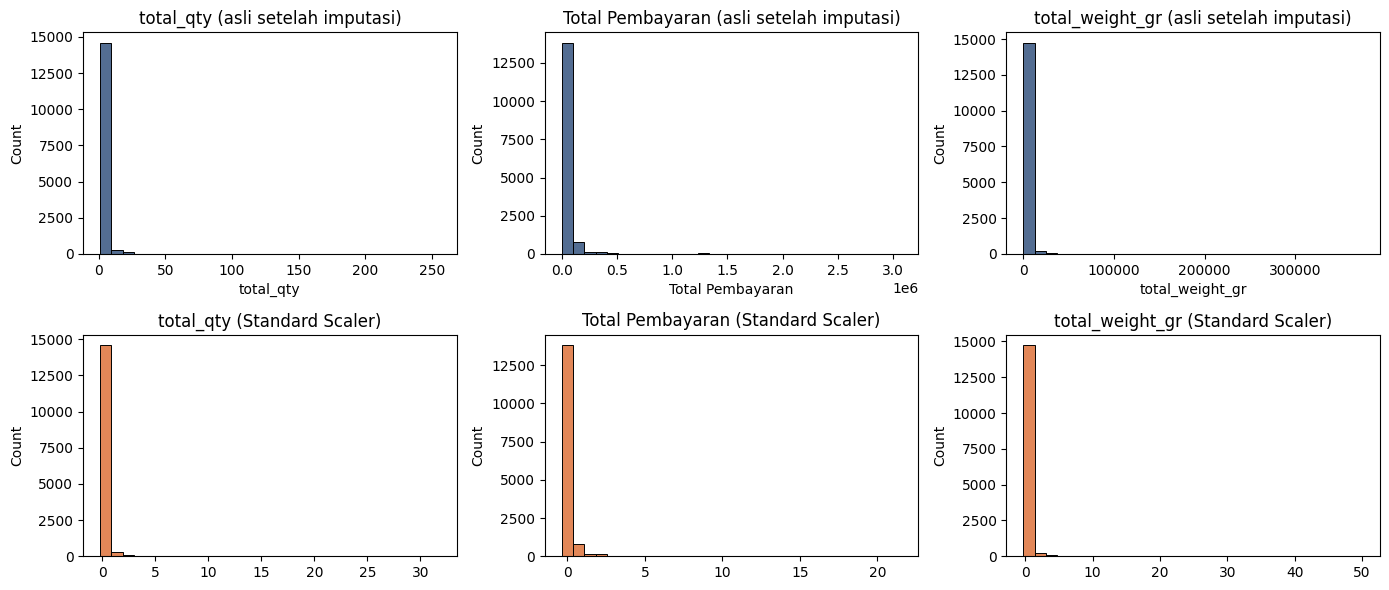

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import (MinMaxScaler, StandardScaler, RobustScaler)
from sklearn.model_selection import train_test_split # Import train_test_split
from sklearn.impute import SimpleImputer # Import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
import os # Import the os module

# Create the 'output' directory if it doesn't exist
output_dir = 'output'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Direktori '{output_dir}' berhasil dibuat.")

# Kolom numerik yang relevan dari DataFrame 'df' yang sudah ada
kolom_numerik = ['total_qty', 'Total Pembayaran', 'total_weight_gr']

# Membagi DataFrame 'df' menjadi data latih dan data uji
# Menggunakan df.copy() untuk menghindari SettingWithCopyWarning
X = df[kolom_numerik].copy()

X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

# -- Imputasi nilai yang hilang --
# Inisialisasi imputer (mengisi dengan rata-rata)
imputer = SimpleImputer(strategy='mean')

# Fit imputer pada data latih dan transformasikan data latih
X_train_imputed = imputer.fit_transform(X_train)
# Transformasikan data uji menggunakan imputer yang sama
X_test_imputed = imputer.transform(X_test)

# Konversi kembali ke DataFrame untuk mempertahankan nama kolom (opsional, tapi bagus untuk dibaca)
X_train_imputed_df = pd.DataFrame(X_train_imputed, columns=kolom_numerik, index=X_train.index)
X_test_imputed_df = pd.DataFrame(X_test_imputed, columns=kolom_numerik, index=X_test.index)


# -- Inisialisasi scaler --
skalers = {
    'MinMax'   : MinMaxScaler(),
    'Standard' : StandardScaler(),
    'Robust'   : RobustScaler(),
}

# Loop untuk setiap scaler
for nama, skaler in skalers.items():
    skaler.fit(X_train_imputed_df)                          # Pelajari dari data latih yang sudah diimputasi
    X_train_scaled = skaler.transform(X_train_imputed_df)   # Terapkan ke latih
    X_test_scaled  = skaler.transform(X_test_imputed_df)    # Terapkan ke uji

    # Menampilkan mean dan std dari data latih yang sudah diskalakan
    print(f'{nama} Scaler:')
    print(f'  Mean (train scaled): {np.mean(X_train_scaled):.4f}')
    print(f'  Std Dev (train scaled): {np.std(X_train_scaled):.4f}\n')

# -- Visualisasi distribusi sebelum dan sesudah skaling --
fig, axes = plt.subplots(2, len(kolom_numerik), figsize=(14, 6))
for i, col in enumerate(kolom_numerik):
    # Plot distribusi asli (setelah imputasi untuk konsistensi, atau bisa juga sebelum imputasi)
    sns.histplot(X_train_imputed_df[col], ax=axes[0, i], bins=30, color='#1A3C6E')
    axes[0, i].set_title(f'{col} (asli setelah imputasi)')

    # Plot distribusi setelah Standard Scaling
    # Lakukan skaling lagi untuk visualisasi agar konsisten dengan cara plot sebelumnya
    X_std_col = StandardScaler().fit_transform(X_train_imputed_df[[col]]).ravel()
    sns.histplot(X_std_col, ax=axes[1, i], bins=30, color='#D95F20')
    axes[1, i].set_title(f'{col} (Standard Scaler)')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'distribusi_skaling.pdf')) # Use os.path.join for path construction
print("Visualisasi distribusi disimpan di 'output/distribusi_skaling.pdf'")

### Encoding Variabel Kategorikal: Label dan Ordinal Encoding

Dalam *machine learning*, model umumnya bekerja dengan data numerik. Oleh karena itu, variabel kategorikal (yaitu, data yang mewakili kelompok atau kategori) perlu diubah menjadi format numerik. Dua teknik umum untuk ini adalah Label Encoding dan Ordinal Encoding.

1.  **Label Encoding**:
    *   **Tujuan**: Mengubah setiap label unik dalam kolom kategorikal menjadi nilai integer.
    *   **Kapan digunakan**: Ideal untuk variabel kategorikal nominal yang tidak memiliki urutan atau hierarki intrinsik (misalnya, 'Merah', 'Hijau', 'Biru' dapat diubah menjadi 0, 1, 2 secara acak). Penting untuk berhati-hati saat menggunakannya pada fitur input karena model mungkin menginterpretasikan angka-angka ini sebagai urutan atau prioritas, yang bisa menyesatkan jika tidak ada.
    *   **Catatan**: Sering digunakan untuk mengkodekan variabel target (dependent variable) yang bersifat kategorikal.

2.  **Ordinal Encoding**:
    *   **Tujuan**: Mengubah setiap label unik dalam kolom kategorikal menjadi nilai integer berdasarkan urutan yang ditentukan.
    *   **Kapan digunakan**: Cocok untuk variabel kategorikal ordinal yang memiliki urutan atau tingkatan yang bermakna (misalnya, 'Sangat Tidak Puas', 'Tidak Puas', 'Netral', 'Puas', 'Sangat Puas' dapat diubah menjadi 0, 1, 2, 3, 4 secara berurutan).
    *   **Keuntungan**: Mempertahankan informasi urutan, yang dapat bermanfaat untuk model tertentu.

Dalam blok kode di bawah, kita akan mendemonstrasikan kedua teknik ini:
*   `LabelEncoder` akan diterapkan pada kolom `product_categories` untuk menunjukkan pemetaan setiap kategori produk ke nilai numerik.
*   `OrdinalEncoder` akan diterapkan pada kolom `tingkat_kepuasan` (yang kita buat secara acak untuk demonstrasi) dengan urutan yang telah ditentukan sebelumnya.

In [ ]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
import pandas as pd
import numpy as np # Import numpy for np.random.choice

# Tambahkan kolom 'tingkat_kepuasan' buatan untuk demonstrasi
# Pilih dari nilai-nilai yang akan digunakan dalam OrdinalEncoder
pilihan_kepuasan = ['Sangat Tidak Puas', 'Tidak Puas', 'Netral', 'Puas', 'Sangat Puas']
df['tingkat_kepuasan'] = np.random.choice(pilihan_kepuasan, size=len(df))

# Label Encoding: HANYA untuk variabel target/ ordinal
le = LabelEncoder()
df['product_categories_encoded'] = le.fit_transform(df['product_categories'])
# Simpan pemetaan untuk keperluan interpretasi
peta_label = dict(zip(le.classes_, le.transform(le.classes_)))
print('Pemetaan Label Encoding (product_categories):', peta_label)

# Ordinal Encoding: untuk variabel dengan urutan bermakna
urutan_kepuasan = [['Sangat Tidak Puas', 'Tidak Puas', 'Netral', 'Puas', 'Sangat Puas']]

oe = OrdinalEncoder(categories=urutan_kepuasan,
    handle_unknown='use_encoded_value',
      unknown_value=-1)

df['kepuasan_encoded'] = oe.fit_transform(df[['tingkat_kepuasan']])
print('\nContoh hasil Ordinal Encoding:')
print(df[['tingkat_kepuasan', 'kepuasan_encoded']].drop_duplicates())

Pemetaan Label Encoding (product_categories): {'Aksesoris ID Card': np.int64(0), 'Aksesoris ID Card, Aksesoris Pintu': np.int64(1), 'Aksesoris ID Card, Aksesoris Pintu, Botol / Gelas / Mug, Peralatan Makan, Sapu / Pembersih Lantai': np.int64(2), 'Aksesoris ID Card, Bangku / Kursi Kecil, Botol / Gelas / Mug, Mangkok Sambal / Saus, Nampan / Tray, Peralatan Makan, Perlengkapan Packing, Plastik / Wadah Plastik, Saringan / Strainer, Talenan, Toples / Sealware': np.int64(3), 'Aksesoris ID Card, Keranjang, Nampan / Tray, Other, Toples / Sealware': np.int64(4), 'Aksesoris ID Card, Other, Sapu / Pembersih Lantai, Teko / Jug': np.int64(5), 'Aksesoris ID Card, Pisau / Alat Potong': np.int64(6), 'Aksesoris ID Card, Teko / Jug': np.int64(7), 'Aksesoris Mandi': np.int64(8), 'Aksesoris Mandi, Aksesoris Pintu': np.int64(9), 'Aksesoris Mandi, Aksesoris Pintu, Keranjang': np.int64(10), 'Aksesoris Mandi, Aksesoris Pintu, Plastik / Wadah Plastik': np.int64(11), 'Aksesoris Mandi, Baskom / Mangkok Besar, Sp

### Encoding Variabel Kategorikal: One-Hot Encoding

**One-Hot Encoding (OHE)** adalah teknik yang digunakan untuk mengubah variabel kategorikal nominal (tanpa urutan) menjadi format numerik biner. Untuk setiap kategori unik dalam suatu fitur, OHE akan membuat kolom biner baru. Jika sebuah observasi termasuk dalam kategori tersebut, nilai pada kolom baru akan menjadi 1; jika tidak, nilainya akan menjadi 0.

**Mengapa OHE Penting?**
*   Banyak algoritma *machine learning* tidak dapat bekerja langsung dengan data kategorikal.
*   OHE menghindari masalah yang timbul dari Label Encoding, di mana model mungkin secara keliru mengasumsikan hubungan ordinal (urutan) antar kategori yang tidak ada.

**Pilihan Implementasi: `pandas.get_dummies` vs `sklearn.preprocessing.OneHotEncoder`**

Ada dua cara umum untuk melakukan One-Hot Encoding di Python:

1.  **`pandas.get_dummies()`**:
    *   **Mudah Digunakan**: Langsung bekerja dengan DataFrame pandas.
    *   **Otomatis Menangani Kolom Kategorikal**: Secara otomatis mendeteksi kolom bertipe `object` atau `category` dan menerapkannya pada kolom tersebut (atau bisa ditentukan secara eksplisit).
    *   **`drop_first=True`**: Parameter ini sangat berguna untuk menghindari masalah *multikolinearitas* (multicollinearity) dengan menghapus kolom biner pertama untuk setiap fitur kategorikal. Ini berarti jika ada N kategori, akan dibuat N-1 kolom baru.
    *   **Kelemahan**: Sulit untuk menangani kategori baru yang mungkin muncul di data uji atau data baru setelah model dilatih, serta konsistensi dalam *mapping* kategori antara *training* dan *testing* data.

2.  **`sklearn.preprocessing.OneHotEncoder`**:
    *   **Fleksibel dan Konsisten**: Ini adalah pilihan yang lebih disukai untuk *pipeline machine learning* karena memungkinkan Anda untuk `fit` encoder pada data latih (`X_train`) dan kemudian `transform` data latih dan data uji (`X_test`) menggunakan pemetaan yang sama. Ini memastikan konsistensi.
    *   **`drop='first'`**: Mirip dengan `drop_first=True` di pandas, ini juga digunakan untuk mengatasi *multikolinearitas*.
    *   **`sparse_output=False`**: Mengembalikan array NumPy padat (dense) daripada *sparse matrix* (lebih mudah dibaca untuk demonstrasi, tetapi *sparse matrix* lebih efisien memori untuk dataset besar).
    *   **`handle_unknown='ignore'`**: Parameter ini penting untuk menangani kategori yang tidak terlihat selama fase `fit` (misalnya, kategori baru di data uji). Jika kategori baru muncul, kolom biner yang sesuai akan diisi dengan nol, mencegah *error*.
    *   **Output**: Secara default mengembalikan *NumPy array*, sehingga perlu dikonversi kembali ke DataFrame jika ingin mempertahankan struktur data tabular dengan nama kolom yang mudah dipahami (`get_feature_names_out`).

Dalam blok kode di bawah, kita akan mendemonstrasikan kedua metode ini pada kolom `'Kota/Kabupaten'`, `'Metode Pembayaran'`, dan `'jenis_kelamin'` (yang dibuat untuk tujuan demonstrasi).

In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
import numpy as np # Import numpy for np.random.choice

# Tambahkan kolom 'jenis_kelamin' buatan untuk demonstrasi
pilihan_jenis_kelamin = ['Laki-laki', 'Perempuan']
df['jenis_kelamin'] = np.random.choice(pilihan_jenis_kelamin, size=len(df))

# OHE dengan pandas get_dummies
df_ohe_pd = pd.get_dummies(df, columns=['Kota/Kabupaten', 'Metode Pembayaran'], drop_first=True, prefix_sep='_')
print("DataFrame dengan One-Hot Encoding (pandas.get_dummies):")
print(df_ohe_pd.head())

# OHE dengan sklearn
ohe = OneHotEncoder(
    drop='first',          # Hapus kategori pertama (multikolinearitas)
    sparse_output=False,   # Output array padat, bukan sparse matrix
    handle_unknown='ignore' # Tangani kategori baru saat inferensi
)

kolom_ohe = ['Kota/Kabupaten', 'Metode Pembayaran', 'jenis_kelamin']
arr_ohe = ohe.fit_transform(df[kolom_ohe])

# Buat nama kolom yang deskriptif
nama_kolom_baru = ohe.get_feature_names_out(kolom_ohe)
df_ohe_sklearn = pd.DataFrame(arr_ohe, columns=nama_kolom_baru, index=df.index)

print(f'\nKolom sebelum OHE (sklearn): {len(kolom_ohe)}')
print(f'Kolom sesudah OHE (sklearn): {len(nama_kolom_baru)}')
print('Contoh kolom (sklearn):', nama_kolom_baru[:5])
print("\nDataFrame dengan One-Hot Encoding (sklearn.OneHotEncoder):")
print(df_ohe_sklearn.head())

DataFrame dengan One-Hot Encoding (pandas.get_dummies):
      order_id  total_qty  total_weight_gr  total_returned_qty  Total Diskon  \
0  ORD_0000001        2.0             2000                   0             0   
1  ORD_0000002        1.0              500                   0             0   
2  ORD_0000003        1.0              500                   0             0   
3  ORD_0000004        2.0              400                   0             0   
4  ORD_0000005        3.0             3600                   0             0   

              product_categories  num_product_categories Status Pesanan  \
0                       Celengan                       1        Selesai   
1                       Celengan                       1        Selesai   
2                       Celengan                       1        Selesai   
3          Mangkok Sambal / Saus                       1        Selesai   
4  Keranjang, Other, Tempat Nasi                       3          Batal   

            

### Encoding Variabel Kategorikal Lanjutan: Target Encoding dan Frequency Encoding

Selain One-Hot Encoding, ada teknik *encoding* lain yang lebih canggih, terutama berguna untuk variabel kategorikal dengan banyak kategori (high cardinality) atau ketika ada hubungan antara kategori dan variabel target. Dua di antaranya adalah Target Encoding dan Frequency Encoding.

1.  **Target Encoding (atau Mean Encoding)**:
    *   **Tujuan**: Mengganti setiap kategori dengan nilai rata-rata dari variabel target untuk kategori tersebut. Ini memungkinkan model untuk secara implisit menangkap informasi dari variabel target yang terkait dengan setiap kategori.
    *   **Kapan digunakan**: Sangat efektif untuk variabel kategorikal dengan banyak kategori dan ketika ada korelasi yang kuat antara kategori dan target.
    *   **Penting**: Untuk menghindari *data leakage* (menggunakan informasi dari data uji selama pelatihan), Target Encoding harus dilakukan dengan hati-hati. Teknik yang umum adalah menggunakan *smoothing* (seperti pada contoh di bawah) atau melakukan *encoding* hanya pada data latih dan kemudian memetakan hasilnya ke data uji. *Smoothing* membantu mengurangi dampak *outlier* atau kategori dengan jumlah observasi yang sangat sedikit.

2.  **Frequency Encoding (atau Count Encoding)**:
    *   **Tujuan**: Mengganti setiap kategori dengan jumlah kemunculannya (frekuensi) atau proporsi kemunculannya dalam dataset. Ini memberikan informasi tentang seberapa sering suatu kategori muncul.
    *   **Kapan digunakan**: Berguna ketika frekuensi kemunculan suatu kategori dipercaya memiliki hubungan dengan variabel target. Juga dapat membantu mengurangi dimensi untuk variabel *high cardinality*.
    *   **Kelemahan**: Kategori yang berbeda mungkin memiliki frekuensi yang sama, sehingga mereka akan dienkode menjadi nilai yang sama. Ini dapat menyebabkan hilangnya informasi.

Dalam blok kode di bawah, kita akan mendemonstrasikan kedua teknik ini:
*   Fungsi `target_encoding_smooth` akan dibuat untuk menerapkan Target Encoding dengan *smoothing* pada kolom `'Metode Pembayaran'`, menggunakan kolom `Total Pembayaran_biner` (yang dibuat sebagai contoh target biner) sebagai variabel target.
*   Frequency Encoding akan diterapkan pada kolom `'Kota/Kabupaten'` untuk menunjukkan proporsi kemunculan setiap kota.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# --- Persiapan Data (Split df menjadi df_train dan df_test) ---
# Asumsikan df adalah DataFrame utama yang sudah ada.
# Untuk demonstrasi, kita akan membuat kolom target 'Total Pembayaran_biner'
# sebagai contoh untuk Target Encoding. Anda bisa menggantinya dengan kolom target sesungguhnya.
df['Total Pembayaran_biner'] = (df['Total Pembayaran'] > df['Total Pembayaran'].median()).astype(int)

df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

# Target Encoding dengan smoothing
def target_encoding_smooth(df_train, df_test, kolom_cat, kolom_target, alpha=10):
  """Target Encoding dengan smoothing empirical Bayes.
  alpha: parameter smoothing (semakin besar = semakin konservatif)."""
  global_mean = df_train[kolom_target].mean()

  stats = df_train.groupby(kolom_cat)[kolom_target].agg(['mean', 'count'])
  stats.columns = ['mean_cat', 'count_cat']

  # Formula smoothing: (n * mean_cat + alpha * global_mean) / (n + alpha)
  stats['encoded'] = (
      stats['count_cat'] * stats['mean_cat'] + alpha * global_mean
  ) / (stats['count_cat'] + alpha)

  df_train_enc = df_train.copy()
  df_test_enc  = df_test.copy()

  df_train_enc[f'{kolom_cat}_te'] = df_train[kolom_cat].map(stats['encoded'])
  df_test_enc[f'{kolom_cat}_te']  = df_test[kolom_cat].map(stats['encoded'])

  # Nilai kategori baru di test set diisi dengan global mean
  df_test_enc[f'{kolom_cat}_te'].fillna(global_mean, inplace=True)

  return df_train_enc, df_test_enc, stats

# --- Contoh Penggunaan Target Encoding ---
kolom_kategorikal_te = 'Metode Pembayaran'
kolom_target_te = 'Total Pembayaran_biner' # Menggunakan kolom biner sebagai contoh target

df_train_encoded, df_test_encoded, te_stats = target_encoding_smooth(
    df_train, df_test, kolom_kategorikal_te, kolom_target_te, alpha=20)

print(f"\nTarget Encoding untuk '{kolom_kategorikal_te}':")
print(te_stats)
print("\nContoh df_train setelah Target Encoding:")
print(df_train_encoded[[kolom_kategorikal_te, f'{kolom_kategorikal_te}_te']].head())


# -- Frequency Encoding --
frekuensi_kota = df_train['Kota/Kabupaten'].value_counts(normalize=True)
df_train['kota_freq'] = df_train['Kota/Kabupaten'].map(frekuensi_kota)
df_test['kota_freq']  = df_test['Kota/Kabupaten'].map(frekuensi_kota).fillna(0)

print("\nContoh df_train setelah Frequency Encoding:")
print(df_train[['Kota/Kabupaten', 'kota_freq']].head())


Target Encoding untuk 'Metode Pembayaran':
                           mean_cat  count_cat   encoded
Metode Pembayaran                                       
Alfamart/Alfamidi/Dan+Dan  0.413793         29  0.448168
BCA OneKlik                0.333333          3  0.476533
COD                        0.404762         84  0.422695
COD (Bayar di Tempat)      0.458344       8066  0.458442
Cash On Delivery           0.518072         83  0.514177
Cicilan Kartu Kredit       1.000000          3  0.563489
Indomaret/i.Saku           0.468750         32  0.480005
Kartu Kredit/Debit         0.655844        154  0.637703
Mitra Shopee               0.000000          1  0.474298
Online Payment             0.569501       2223  0.568863
OnlinePayment              0.550000         20  0.524006
Pembayaran dibebaskan      0.000000         11  0.321298
SPay Later                 0.560000         25  0.532450
SPayLater                  0.541544       1023  0.540710
Saldo ShopeePay            0.548525       25

/tmp/ipykernel_931/3559090527.py:34: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_test_enc[f'{kolom_cat}_te'].fillna(global_mean, inplace=True)


### Rekayasa Fitur Waktu Lanjutan (`buat_fitur_waktu`)

Fungsi `buat_fitur_waktu` dirancang untuk mengekstrak berbagai fitur informatif dari kolom bertipe datetime (tanggal dan waktu) dalam DataFrame. Tujuan dari rekayasa fitur waktu ini adalah untuk mengubah informasi tanggal dan waktu mentah menjadi representasi numerik yang dapat digunakan oleh model *machine learning* untuk menangkap pola-pola temporal.

Fitur-fitur yang diekstrak meliputi:

*   **Komponen Kalender Dasar**: Tahun, bulan, hari dalam bulan, hari dalam pekan, jam, kuartal, dan pekan ke- (`waktu_tahun`, `waktu_bulan`, `waktu_hari_bulan`, `waktu_hari_pekan`, `waktu_jam`, `waktu_kuartal`, `waktu_pekan_ke`).
*   **Fitur Biner Kontekstual**: Indikator apakah suatu observasi terjadi di akhir pekan atau jam kerja (`adalah_akhir_pekan`, `adalah_jam_kerja`, `adalah_malam_hari`).
*   **Fitur Siklus (Encoding Trigonometri)**: Representasi sinusoidal dan cosinusoidal dari bulan dan jam (`sin_bulan`, `cos_bulan`, `sin_jam`, `cos_jam`). Ini berguna untuk data musiman atau siklus karena memastikan bahwa awal dan akhir suatu siklus (misalnya, Januari dan Desember) dianggap 'dekat' oleh model.
*   **Selisih Waktu (Lag Features)**: Perhitungan selisih hari antara `order_date` dan `tgl_registrasi` (`hari_sejak_registrasi`), yang bisa mengindikasikan loyalitas atau durasi keanggotaan.

Fungsi ini juga menyertakan penanganan nilai `NaT` (Not a Time) yang mungkin muncul dari konversi datetime yang gagal, menggantinya dengan nilai placeholder `-1` untuk fitur integer.

### Menambahkan Kolom Tanggal Registrasi Dummy

Untuk mendemonstrasikan fitur `hari_sejak_registrasi` yang dihitung dalam fungsi `buat_fitur_waktu`, kita perlu memiliki kolom tanggal registrasi pelanggan. Karena data asli tidak memilikinya, kami akan membuat kolom `tgl_registrasi` *dummy* (contoh) secara acak. Tanggal registrasi ini akan diasumsikan terjadi antara 30 hingga 365 hari sebelum `order_date` yang relevan.

In [ ]:
import numpy as np

# Create a dummy 'tgl_registrasi' column for demonstration purposes
# Assuming registration happened between 30 and 365 days before the order date
df['tgl_registrasi'] = df['order_date'] - pd.to_timedelta(np.random.randint(30, 365, size=len(df)), unit='D')

print("Kolom 'tgl_registrasi' berhasil dibuat.")

Kolom 'tgl_registrasi' berhasil dibuat.


In [ ]:
n_kolom_awal = df.shape[1]

# Apply the function to the dataset using 'order_date'
df = buat_fitur_waktu(df, 'order_date')
print(f'Fitur baru: {df.shape[1] - n_kolom_awal} kolom ditambahkan')

print("\nDataFrame setelah penambahan fitur waktu:")
display(df.head())

Fitur baru: 15 kolom ditambahkan

DataFrame setelah penambahan fitur waktu:


,order_id,total_qty,total_weight_gr,total_returned_qty,Total Diskon,product_categories,num_product_categories,Status Pesanan,Alasan Pembatalan,Opsi Pengiriman,...,waktu_kuartal,waktu_pekan_ke,adalah_akhir_pekan,adalah_jam_kerja,adalah_malam_hari,sin_bulan,cos_bulan,sin_jam,cos_jam,hari_sejak_registrasi
0,ORD_0000001,2.0,2000,0,0,Celengan,1,Selesai,Tidak dibatalkan,Reguler (Cashless)-SPX Standard,...,2.0,14,0,0,0,0.866025,-0.5,0.0,1.0,158
1,ORD_0000002,1.0,500,0,0,Celengan,1,Selesai,Tidak dibatalkan,Hemat Kargo-SPX Hemat,...,2.0,14,0,0,0,0.866025,-0.5,0.0,1.0,61
2,ORD_0000003,1.0,500,0,0,Celengan,1,Selesai,Tidak dibatalkan,Hemat Kargo-SPX Hemat,...,2.0,14,0,0,0,0.866025,-0.5,0.0,1.0,88
3,ORD_0000004,2.0,400,0,0,Mangkok Sambal / Saus,1,Selesai,Tidak dibatalkan,Hemat Kargo-SPX Hemat,...,2.0,14,0,0,0,0.866025,-0.5,0.0,1.0,248
4,ORD_0000005,3.0,3600,0,0,"Keranjang, Other, Tempat Nasi",3,Batal,Dibatalkan oleh Pembeli. Alasan: Ubah Pesanan ...,Hemat Kargo-SPX Hemat,...,2.0,14,0,0,0,0.866025,-0.5,0.0,1.0,244


In [ ]:
import pandas as pd
import numpy as np

def buat_fitur_waktu(df, kolom_waktu):
    "Mengekstrak fitur informatif dari kolom datetime."
    df = df.copy()
    dt = df[kolom_waktu]  # Akses atribut datetime

    # -- Komponen kalender dasar --
    df['waktu_tahun']      = dt.dt.year
    df['waktu_bulan']      = dt.dt.month
    df['waktu_hari_bulan'] = dt.dt.day
    df['waktu_hari_pekan'] = dt.dt.dayofweek
    # 0=Senin, 6=Minggu
    df['waktu_jam']        = dt.dt.hour
    df['waktu_kuartal']    = dt.dt.quarter
    # Handle NaT values by converting to float first, filling NaN, then to int
    df['waktu_pekan_ke']   = dt.dt.isocalendar().week.astype(float).fillna(-1).astype(int)

    # -- Fitur biner kontekstual --
    df['adalah_akhir_pekan'] = (dt.dt.dayofweek >= 5).astype(int)
    df['adalah_jam_kerja']   = dt.dt.hour.between(9, 17).astype(int)
    df['adalah_malam_hari']  = dt.dt.hour.between(18, 23).astype(int)

    # -- Fitur siklus (encoding trigonometri - untuk model linear/NN) --
    # Bulan 1 dan 12 harus 'dekat' satu sama lain dalam ruang fitur
    df['sin_bulan'] = np.sin(2 * np.pi * dt.dt.month / 12)
    df['cos_bulan'] = np.cos(2 * np.pi * dt.dt.month / 12)
    df['sin_jam']   = np.sin(2 * np.pi * dt.dt.hour / 24)
    df['cos_jam']   = np.cos(2 * np.pi * dt.dt.hour / 24)

    # -- Selisih waktu (lag features) --
    # Only calculate if 'tgl_registrasi' exists and dt is not NaT
    if 'tgl_registrasi' in df.columns:
        # Ensure 'tgl_registrasi' is also datetime
        df['tgl_registrasi'] = pd.to_datetime(df['tgl_registrasi'], errors='coerce')
        # Only calculate difference for non-NaT order_date and tgl_registrasi
        valid_dates = (~dt.isna()) & (~df['tgl_registrasi'].isna())
        df.loc[valid_dates, 'hari_sejak_registrasi'] = (dt[valid_dates] - df.loc[valid_dates, 'tgl_registrasi']).dt.days
        df['hari_sejak_registrasi'] = df['hari_sejak_registrasi'].fillna(-1).astype(int)
    else:
        df['hari_sejak_registrasi'] = -1 # Default value if column doesn't exist or not calculated

    return df

# Terapkan ke dataset
# df = buat_fitur_waktu(df, 'waktu_transaksi')
# print(f'Fitur baru: {df.shape[1] - n_kolom_awal} kolom ditambahkan')

### Rekayasa Fitur Numerik Tambahan

Selain imputasi dan skaling, kita dapat membuat fitur numerik baru yang lebih kaya informasi dari fitur yang sudah ada. Ini membantu model menangkap hubungan yang lebih kompleks dalam data. Berikut adalah beberapa contoh teknik rekayasa fitur numerik:

1.  **Fitur Rasio dan Interaksi antar Variabel**:
    *   **Tujuan**: Membuat fitur baru dengan menggabungkan dua atau lebih fitur yang ada melalui operasi matematika (misalnya, pembagian, perkalian) untuk menangkap hubungan atau interaksi antar variabel.
    *   **Contoh**: `harga_per_gram` (harga dibagi berat), `ulasan_per_penjualan` (jumlah ulasan per jumlah terjual), atau `rasio_stok` (stok produk dibandingkan stok maksimum).

2.  **Fitur Agregat Berbasis Kelompok (Group-level Features)**:
    *   **Tujuan**: Menghitung statistik ringkasan (misalnya, rata-rata, jumlah, rank) untuk suatu kelompok observasi dan kemudian menetapkan nilai agregat ini kembali ke setiap observasi dalam kelompok tersebut.
    *   **Contoh**: `harga_rata_toko` (rata-rata harga produk dari toko yang sama), `rank_harga_toko` (peringkat harga produk dalam toko tertentu), atau `n_produk_toko` (jumlah produk yang dijual oleh suatu toko).

3.  **Binning (Mengubah Numerik Kontinu ke Kategoris)**:
    *   **Tujuan**: Mengubah variabel numerik kontinu menjadi variabel kategorikal dengan mengelompokkan nilai-nilai ke dalam 'bin' atau interval.
    *   **Contoh**: `segmen_harga` yang mengklasifikasikan `Total Pembayaran` ke dalam kategori seperti 'Ekonomis', 'Menengah', 'Premium', atau 'Mewah'. `desil_harga` juga mengelompokkan `Total Pembayaran` berdasarkan kuantil untuk frekuensi yang seimbang.

4.  **Fitur Polinomial (Polynomial Features)**:
    *   **Tujuan**: Membuat fitur baru yang merupakan kombinasi pangkat dari fitur yang sudah ada dan interaksi antar fitur. Ini dapat membantu model menangkap hubungan non-linear.
    *   **Contoh**: Dari fitur `harga`, `rating`, dan `jarak_gudang`, kita bisa membuat fitur seperti `harga^2`, `rating^2`, `harga * rating`, dan sebagainya. Ini memungkinkan model untuk belajar pola yang lebih kompleks.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures

# --- Create dummy columns for demonstration purposes ---
# These columns are not in the original df but are needed for the examples below
np.random.seed(42) # for reproducibility
df['id_toko'] = np.random.choice([f'Toko_{i}' for i in range(1, 11)], size=len(df))
df['id_produk'] = np.random.choice([f'PROD_{i}' for i in range(1, 51)], size=len(df))
df['n_ulasan'] = np.random.randint(0, 500, size=len(df))
df['n_terjual'] = np.random.randint(1, 1000, size=len(df))
df['stok'] = np.random.randint(0, 200, size=len(df))
df['rating'] = np.random.uniform(2.5, 5.0, size=len(df))
df['jarak_gudang'] = np.random.randint(10, 500, size=len(df))

# Map original example column names to existing/dummy columns in df
# 'harga' will be mapped to 'Total Pembayaran'
# 'berat_gram' will be mapped to 'total_weight_gr'

# 1. Fitur rasio dan interaksi antar variabel
# Use 'Total Pembayaran' as a proxy for 'harga'
df['harga_per_gram'] = df['Total Pembayaran'] / df['total_weight_gr'].replace(0, np.nan) # Avoid division by zero
df['ulasan_per_penjualan'] = df['n_ulasan'] / (df['n_terjual'] + 1)
df['rasio_stok'] = df['stok'] / (df['stok'].max() + 1)

# 2. Fitur agregat berbasis kelompok (group-level features)
# Berapa rata-rata harga produk dari toko yang sama?
df['harga_rata_toko'] = df.groupby('id_toko')['Total Pembayaran'].transform('mean')
df['rank_harga_toko'] = df.groupby('id_toko')['Total Pembayaran'].rank(pct=True)

# Berapa produk yang dijual oleh toko ini?
df['n_produk_toko'] = df.groupby('id_toko')['id_produk'].transform('count')

# 3. Binning: mengubah numerik kontinu ke kategoris
df['segmen_harga'] = pd.cut(df['Total Pembayaran'],
  bins  = [0, 50_000, 150_000, 500_000, float('inf')], labels= ['Ekonomis', 'Menengah', 'Premium', 'Mewah'], right = True )

# Atau binning berdasarkan kuantil (frekuensi seimbang)
df['desil_harga'] = pd.qcut(df['Total Pembayaran'], q=10, labels=False, duplicates='drop')

# 4. Fitur polinomial (polynomial features)
# Membuat fitur x, x^2, x^3, dan interaksi x*y dari fitur numerik
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)

# Check for NaNs and inf in selected columns before fitting PolynomialFeatures
fitur_dasar = df[['Total Pembayaran', 'rating', 'jarak_gudang']].replace([np.inf, -np.inf], np.nan).fillna(0).values

fitur_poly  = poly.fit_transform(fitur_dasar)
nama_poly   = poly.get_feature_names_out(['Total_Pembayaran', 'rating', 'jarak_gudang'])

# Create a DataFrame for polynomial features, ensuring index alignment
df_poly = pd.DataFrame(fitur_poly, columns=nama_poly, index=df.index)

# Concatenate df_poly with the main df, dropping original columns if desired or keeping them separate
# For this demonstration, we will just print the info as df_poly is already created
# df = pd.concat([df, df_poly], axis=1)

print(f'Fitur asli: 3 -> Fitur polinomial: {len(nama_poly)}')
print("\nDataFrame dengan fitur rekayasa:")
display(df.head())

Fitur asli: 3 -> Fitur polinomial: 9

DataFrame dengan fitur rekayasa:


,order_id,total_qty,total_weight_gr,total_returned_qty,Total Diskon,product_categories,num_product_categories,Status Pesanan,Alasan Pembatalan,Opsi Pengiriman,...,rating,jarak_gudang,harga_per_gram,ulasan_per_penjualan,rasio_stok,harga_rata_toko,rank_harga_toko,n_produk_toko,segmen_harga,desil_harga
0,ORD_0000001,2.0,2000,0,0,Celengan,1,Selesai,Tidak dibatalkan,Reguler (Cashless)-SPX Standard,...,4.031709,235,19.150,6.979167,0.995,55779.993169,0.710720,1903,Ekonomis,6
1,ORD_0000002,1.0,500,0,0,Celengan,1,Selesai,Tidak dibatalkan,Hemat Kargo-SPX Hemat,...,4.763480,346,37.152,0.089691,0.970,54116.732796,0.383871,1860,Ekonomis,2
2,ORD_0000003,1.0,500,0,0,Celengan,1,Selesai,Tidak dibatalkan,Hemat Kargo-SPX Hemat,...,4.263132,442,14.138,0.714667,0.520,50090.911076,0.159212,1878,Ekonomis,0
3,ORD_0000004,2.0,400,0,0,Mangkok Sambal / Saus,1,Selesai,Tidak dibatalkan,Hemat Kargo-SPX Hemat,...,4.606508,113,80.500,0.077764,0.210,51991.552575,0.633584,1864,Ekonomis,5
4,ORD_0000005,3.0,3600,0,0,"Keranjang, Other, Tempat Nasi",3,Batal,Dibatalkan oleh Pembeli. Alasan: Ubah Pesanan ...,Hemat Kargo-SPX Hemat,...,3.529461,13,0.000,0.249622,0.900,55779.993169,0.065160,1903,NaN,0


### Rekayasa Fitur Teks

Untuk data yang mengandung informasi tekstual, seperti ulasan produk atau deskripsi, kita dapat mengekstrak fitur-fitur yang relevan untuk analisis. Rekayasa fitur teks mengubah data teks mentah menjadi representasi numerik yang dapat dipahami oleh model *machine learning*.

Dalam blok kode ini, kita akan mendemonstrasikan dua jenis rekayasa fitur teks:

1.  **Fitur Statistik Dasar dari Teks**:
    *   **Tujuan**: Mengekstrak karakteristik kuantitatif sederhana dari teks yang dapat memberikan gambaran tentang struktur atau 'kepadatan' teks.
    *   **Contoh**: Jumlah karakter, jumlah kata, jumlah kalimat, indikator keberadaan tanda seru, jumlah angka, dan proporsi huruf kapital. Fitur-fitur ini seringkali berguna untuk analisis sentimen, deteksi *spam*, atau mengukur kompleksitas teks.

2.  **TF-IDF (Term Frequency-Inverse Document Frequency)**:
    *   **Tujuan**: Mengubah koleksi dokumen teks menjadi matriks fitur numerik. TF-IDF adalah ukuran statistik yang digunakan untuk mengevaluasi seberapa penting sebuah kata bagi sebuah dokumen dalam koleksi atau korpus. Semakin tinggi nilai TF-IDF suatu kata, semakin relevan kata tersebut dalam dokumen tersebut dibandingkan dengan dokumen lain dalam korpus.
    *   **Konsep**: Menggabungkan dua metrik:
        *   **Term Frequency (TF)**: Seberapa sering sebuah kata muncul dalam sebuah dokumen.
        *   **Inverse Document Frequency (IDF)**: Ukuran seberapa jarang sebuah kata muncul di seluruh koleksi dokumen. Kata-kata yang umum (misalnya, "dan", "yang") akan memiliki nilai IDF yang rendah, sedangkan kata-kata unik atau spesifik akan memiliki nilai IDF yang tinggi.
    *   **Kapan digunakan**: Sangat populer dalam *information retrieval*, *text summarization*, dan *text classification*. Ini membantu mengurangi bobot kata-kata yang sangat umum dan meningkatkan bobot kata-kata yang lebih diskriminatif.

In [ ]:
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# --- Create dummy 'teks_ulasan' column for demonstration purposes ---
np.random.seed(42) # for reproducibility
# Generate some dummy text for 'teks_ulasan' column
dummy_reviews = [
    "Produk ini sangat bagus dan sesuai deskripsi! Saya suka sekali.",
    "Kualitasnya standar, tidak terlalu istimewa. Pengiriman cepat.",
    "Sangat kecewa dengan produk ini. Tidak berfungsi dengan baik.",
    "Lumayanlah untuk harganya. Cukup puas.",
    "Pelayanan penjual ramah, produk oke. Terima kasih!",
    "Pengiriman lambat sekali. Produknya lumayan.",
    "Bintang 5! Rekomendasi banget. Akan beli lagi.",
    "Not bad, but could be better. The material feels cheap.",
    "Packing rapi dan aman. Barang sampai tanpa cacat.",
    "Ukuran tidak sesuai deskripsi. Sedikit kecewa.",
    "Produk bagus, harga terjangkau. Good job!",
    "Ini palsu! Jangan beli di toko ini.",
    "Sangat membantu pekerjaan saya. Love it!",
    "Warnanya tidak seperti yang di gambar. Agak pudar."
]
df['teks_ulasan'] = np.random.choice(dummy_reviews, size=len(df))

# Fitur statistik dari teks (pra-pemodelan NLP)
def buat_fitur_teks_dasar(df, kolom_teks):
  "Ekstrak fitur statistik dari teks"
  teks = df[kolom_teks].fillna('')

  df['teks_n_karakter']  = teks.str.len()
  df['teks_n_kata']      = teks.str.split().str.len()
  df['teks_n_kalimat']   = teks.str.count('[.!?]') + 1
  df['teks_ada_tanda_seru'] = teks.str.contains('!').astype(int)
  df['teks_n_angka']     = teks.str.count(r'\d+')
  df['teks_proporsi_huruf_besar'] = (
    teks.str.count(r'[A-Z]') / (teks.str.len() + 1))
  return df

# TF-IDF: Representasi vektor berbobot
# (Materi lengkap TF-IDF ada di Bab 7)
tfidf = TfidfVectorizer(
  max_features = 500,    # Ambil 500 kata TF-IDF tertinggi
  ngram_range   = (1, 2), # Unigram + bigram
  min_df       = 5, # Abaikan kata yang muncul < 5 dokumen
  max_df       = 0.9,  # Abaikan kata yang muncul di > 90% dokumen
  sublinear_tf = True # Gunakan log(TF) alih-alih TF
)

X_tfidf = tfidf.fit_transform(df['teks_ulasan'])
df_tfidf = pd.DataFrame(X_tfidf.toarray(),
  columns=tfidf.get_feature_names_out())
print(f'Dimensi TF-IDF: {X_tfidf.shape}')

Dimensi TF-IDF: (18868, 162)


### Seleksi Fitur (Feature Selection)

**Seleksi fitur** adalah proses memilih subset fitur (kolom) yang paling relevan, tidak redundan, dan informatif dari dataset asli untuk digunakan dalam membangun model *machine learning*. Tujuan utamanya adalah untuk:

1.  **Mengurangi *Overfitting***: Dengan menghilangkan fitur yang tidak relevan atau redundan, model cenderung tidak 'menghafal' data latih dan bergeneralisasi lebih baik ke data baru.
2.  **Meningkatkan Akurasi Model**: Fitur yang tepat dapat membantu model menemukan pola yang lebih kuat dan menghasilkan prediksi yang lebih akurat.
3.  **Mempercepat Waktu Pelatihan**: Model yang dilatih dengan lebih sedikit fitur akan membutuhkan lebih sedikit komputasi.
4.  **Memperbaiki Interpretasi Model**: Model dengan fitur yang lebih sedikit dan lebih bermakna akan lebih mudah dipahami dan dijelaskan.

Ada tiga kategori utama metode seleksi fitur:

1.  **Metode Filter (Filter Methods)**:
    *   **Konsep**: Mengevaluasi relevansi fitur secara independen dari model *machine learning* yang digunakan. Mereka menggunakan metrik statistik untuk menilai hubungan antara setiap fitur dan variabel target.
    *   **Contoh**: Skor korelasi, Chi-square, Mutual Information, ANOVA F-value.
    *   **Kelebihan**: Cepat dan murah secara komputasi. Tidak ada risiko *overfitting* yang terkait dengan model seleksi.
    *   **Kekurangan**: Mengabaikan interaksi antar fitur.

2.  **Metode *Wrapper* (Wrapper Methods)**:
    *   **Konsep**: Menggunakan model *machine learning* itu sendiri untuk mengevaluasi subset fitur yang berbeda. Mereka mencari subset fitur terbaik yang memberikan kinerja model terbaik.
    *   **Contoh**: Forward Selection, Backward Elimination, Recursive Feature Elimination (RFE).
    *   **Kelebihan**: Dapat menemukan subset fitur yang optimal untuk model tertentu dan mempertimbangkan interaksi fitur.
    *   **Kekurangan**: Mahal secara komputasi karena melibatkan pelatihan model berulang kali.

3.  **Metode *Embedded* (Embedded Methods)**:
    *   **Konsep**: Proses seleksi fitur terintegrasi ke dalam proses pelatihan model *machine learning*. Model itu sendiri melakukan seleksi fitur selama pelatihannya.
    *   **Contoh**: Regularisasi (Lasso, Ridge), Pohon Keputusan (Decision Trees), Random Forest (menggunakan *feature importance*).
    *   **Kelebihan**: Menyeimbangkan kecepatan metode filter dan akurasi metode *wrapper*. Mempertimbangkan interaksi fitur.
    *   **Kekurangan**: Seleksi fitur spesifik untuk model yang digunakan.

Dalam blok kode di bawah ini, kita akan mendemonstrasikan dua pendekatan:

*   **Metode Filter**: Menggunakan **Mutual Information** untuk mengukur ketergantungan antara setiap fitur numerik dan variabel target. Fitur dengan skor Mutual Information yang lebih tinggi dianggap lebih relevan.
*   **Metode *Embedded***: Menggunakan **Feature Importance** dari model **Random Forest Classifier**. Random Forest secara inheren dapat menilai seberapa besar kontribusi setiap fitur terhadap keputusan klasifikasi.

Fitur terpilih: ['Total Pembayaran', 'total_weight_gr', 'total_qty']


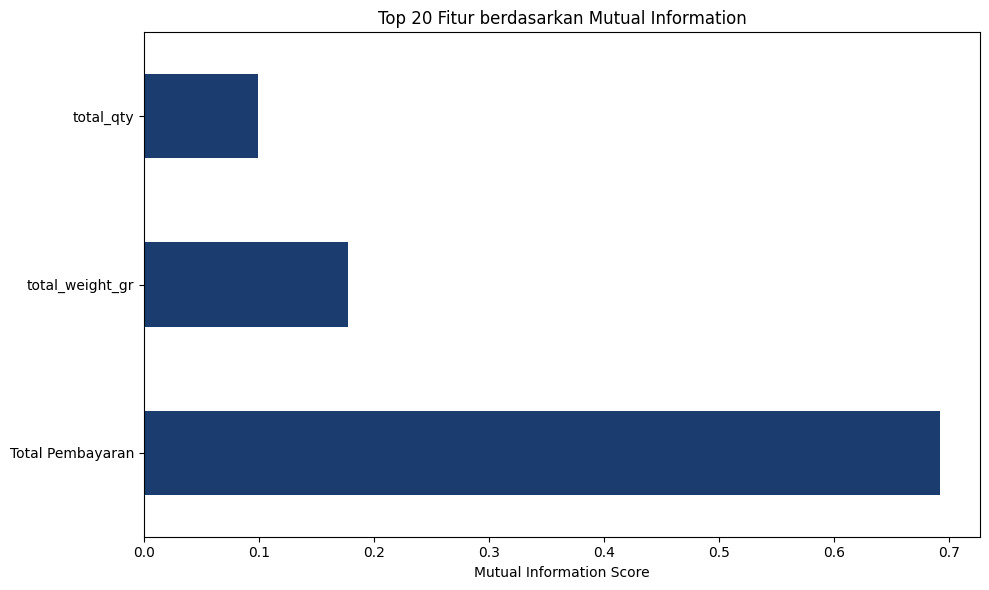

In [ ]:
from sklearn.feature_selection import (SelectKBest, f_classif, RFE, SelectFromModel)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split # Import train_test_split
from sklearn.impute import SimpleImputer # Import SimpleImputer

# --- FIX: Define X, y and perform train-test split ---
# Assuming 'df' is available from previous cells.
# Define features (X) using the numerical columns identified earlier
kolom_numerik = ['total_qty', 'Total Pembayaran', 'total_weight_gr']
X = df[kolom_numerik].copy() # Use .copy() to avoid SettingWithCopyWarning

# Define target (y) using the binary target created in previous cells
y = df['Total Pembayaran_biner']

# Perform train-test split to get X_train, X_test, y_train, y_test consistently
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- FIX: Impute missing values in X_train and X_test ---
# Initialize imputer (fill with mean)
imputer = SimpleImputer(strategy='mean')

# Fit imputer on training data and transform both train and test data
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed  = imputer.transform(X_test)

# Convert imputed arrays back to DataFrames to retain column names
X_train_imputed_df = pd.DataFrame(X_train_imputed, columns=kolom_numerik, index=X_train.index)
X_test_imputed_df  = pd.DataFrame(X_test_imputed, columns=kolom_numerik, index=X_test.index)

# Now use the imputed DataFrames for feature selection and model training

# Filter: Mutual Information
from sklearn.feature_selection import mutual_info_classif
mi_scores = mutual_info_classif(X_train_imputed_df, y_train, random_state=42)
mi_series = pd.Series(mi_scores, index=X_train_imputed_df.columns)
mi_series = mi_series.sort_values(ascending=False)

# Visualisasi feature importance
fig, ax = plt.subplots(figsize=(10, 6))
mi_series.head(20).plot(kind='barh', ax=ax, color='#1A3C6E')
ax.set_xlabel('Mutual Information Score')
ax.set_title('Top 20 Fitur berdasarkan Mutual Information')
plt.tight_layout()

# Embedded: Feature Importance Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_imputed_df, y_train)

importances = pd.Series(rf.feature_importances_, index=X_train_imputed_df.columns)
top_fitur = importances.nlargest(15).index

# Pilih hanya top 15 fitur untuk model akhir
X_train_selected = X_train_imputed_df[top_fitur]
X_test_selected  = X_test_imputed_df[top_fitur]
print(f'Fitur terpilih: {list(top_fitur)}')